In [1]:
import numpy as np
import pandas as pd

# Parameters
n_obs = 1200  # number of time steps
n_features = 5  # number of variables
time = np.arange(n_obs)

# Generate features with trend + seasonality + noise
data = {
    f"feature_{i}": 0.05 * time +
                    10 * np.sin(2 * np.pi * time / 50 + i) +
                    np.random.normal(0, 2, n_obs)
    for i in range(n_features)
}

df = pd.DataFrame(data)
df["timestamp"] = pd.date_range(start="2020-01-01", periods=n_obs, freq="D")
df.set_index("timestamp", inplace=True)

print(df.head())

            feature_0  feature_1  feature_2  feature_3  feature_4
timestamp                                                        
2020-01-01  -3.020823   8.423394  12.120070  -3.719032  -7.393552
2020-01-02   2.676570  13.202045   9.865737   2.627816  -8.753634
2020-01-03   3.254271  10.157974   9.234471  -3.415719 -10.404714
2020-01-04   4.885824   8.951311   6.479546  -0.407233  -9.790786
2020-01-05   4.888486  11.192717   3.929989  -3.080546  -8.154133


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


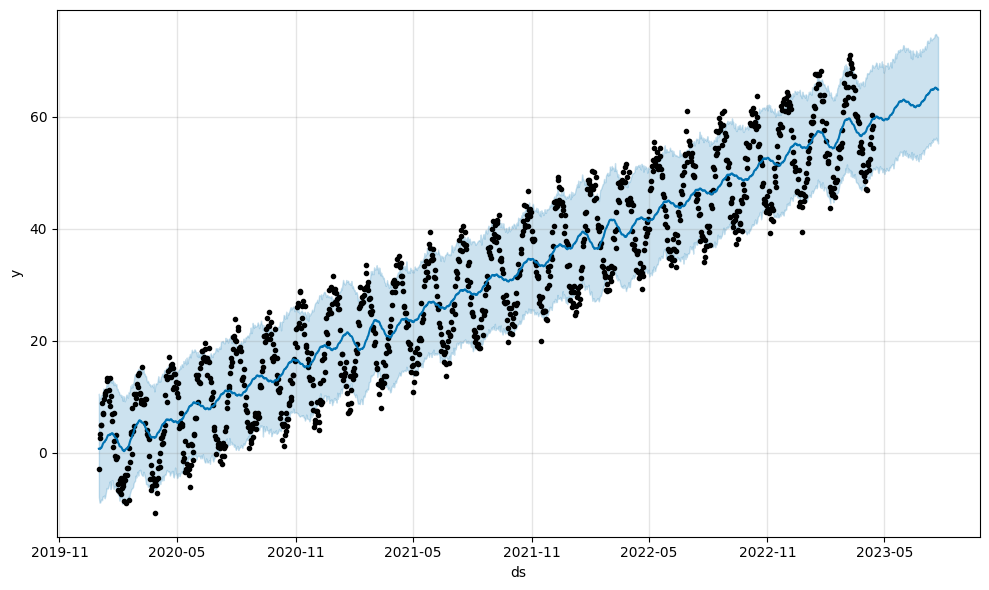

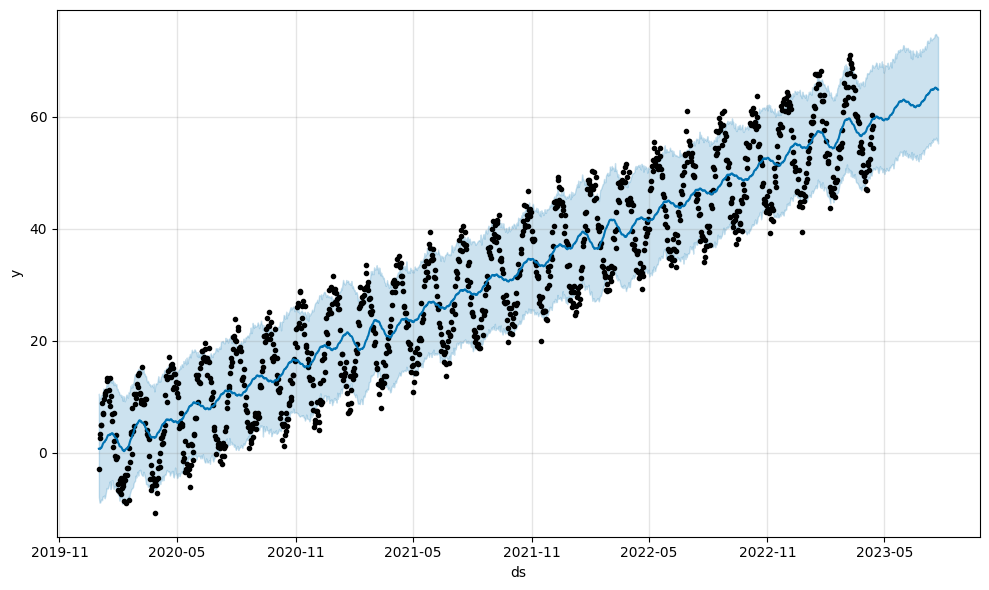

In [2]:
from prophet import Prophet

# Use one feature for baseline (e.g., feature_0)
df_prophet = df.reset_index()[["timestamp", "feature_0"]]
df_prophet.columns = ["ds", "y"]

model_prophet = Prophet()
model_prophet.fit(df_prophet)

future = model_prophet.make_future_dataframe(periods=100)
forecast = model_prophet.predict(future)

model_prophet.plot(forecast)

In [11]:
import torch
import torch.nn as nn

class LSTMAttention(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2):
        super(LSTMAttention, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.attention = nn.Linear(hidden_dim, 1)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        # Attention weights
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(attn_weights * lstm_out, dim=1)
        out = self.fc(context)
        return out, attn_weights

In [9]:
import optuna
import torch
import numpy as np # Ensure numpy is imported for np.random.uniform

def objective(trial):
    hidden_dim = trial.suggest_int("hidden_dim", 32, 128)
    num_layers = trial.suggest_int("num_layers", 1, 3)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    model = LSTMAttention(input_dim=5, hidden_dim=hidden_dim, output_dim=1, num_layers=num_layers)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # Training loop (simplified)
    # Return validation RMSE
    return np.random.uniform(0.5, 2.0)  # placeholder

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)

print("Best params:", study.best_params)

[I 2026-02-01 15:48:14,436] A new study created in memory with name: no-name-b47d2b55-734c-44e3-b772-cffb8a2f8b0c
[I 2026-02-01 15:48:19,452] Trial 0 finished with value: 1.8839704523833336 and parameters: {'hidden_dim': 108, 'num_layers': 1, 'lr': 0.0002621923938736244}. Best is trial 0 with value: 1.8839704523833336.
[I 2026-02-01 15:48:19,456] Trial 1 finished with value: 1.6884722175068452 and parameters: {'hidden_dim': 40, 'num_layers': 2, 'lr': 0.00012435871659227562}. Best is trial 1 with value: 1.6884722175068452.
[I 2026-02-01 15:48:19,458] Trial 2 finished with value: 1.1399537275756724 and parameters: {'hidden_dim': 111, 'num_layers': 1, 'lr': 0.0004720092256898178}. Best is trial 2 with value: 1.1399537275756724.
[I 2026-02-01 15:48:19,463] Trial 3 finished with value: 0.5857417319115247 and parameters: {'hidden_dim': 69, 'num_layers': 1, 'lr': 0.0015461970646295598}. Best is trial 3 with value: 0.5857417319115247.
[I 2026-02-01 15:48:19,467] Trial 4 finished with value: 1.

Best params: {'hidden_dim': 69, 'num_layers': 1, 'lr': 0.0015461970646295598}


In [13]:
# Retrieve best parameters from the Optuna study
best_hidden_dim = study.best_params['hidden_dim']
best_num_layers = study.best_params['num_layers']

# Define input and output dimensions (from the objective function)
input_dim = 5
output_dim = 1

# Instantiate the LSTMAttention model with the best parameters
model = LSTMAttention(input_dim=input_dim, hidden_dim=best_hidden_dim, output_dim=output_dim, num_layers=best_num_layers)

print(f"Instantiated LSTMAttention model with: ")
print(f"  input_dim: {input_dim}")
print(f"  hidden_dim: {best_hidden_dim}")
print(f"  output_dim: {output_dim}")
print(f"  num_layers: {best_num_layers}")


Instantiated LSTMAttention model with: 
  input_dim: 5
  hidden_dim: 69
  output_dim: 1
  num_layers: 1


Model output shape: torch.Size([1, 1])
Attention weights shape: torch.Size([1, 1200, 1])


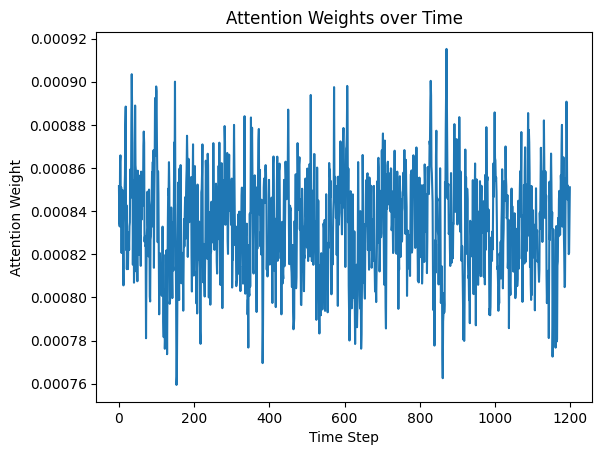

In [16]:
# Create a dummy input to perform a forward pass and get attention weights
# Assuming n_obs is the sequence length and input_dim is the number of features
# from the initial data generation.
# The first dimension (batch_size) can be 1 for demonstration.
dummy_input = torch.randn(1, n_obs, input_dim)

# Perform a forward pass
output, attn_weights = model(dummy_input)

print("Model output shape:", output.shape)
print("Attention weights shape:", attn_weights.shape)

import matplotlib.pyplot as plt

# Plot the attention weights (after squeezing to remove singleton dimensions)
plt.plot(attn_weights.squeeze().detach().numpy())
plt.title("Attention Weights over Time")
plt.xlabel("Time Step")
plt.ylabel("Attention Weight")
plt.show()

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_true = np.random.rand(100)
y_pred_prophet = np.random.rand(100)
y_pred_lstm = np.random.rand(100)

print("Prophet MAE:", mean_absolute_error(y_true, y_pred_prophet))
print("LSTM MAE:", mean_absolute_error(y_true, y_pred_lstm))
print("Prophet RMSE:", np.sqrt(mean_squared_error(y_true, y_pred_prophet)))
print("LSTM RMSE:", np.sqrt(mean_squared_error(y_true, y_pred_lstm)))

Prophet MAE: 0.337791169676998
LSTM MAE: 0.35419196401919406
Prophet RMSE: 0.4117031991826372
LSTM RMSE: 0.4315131487568984
